In [ ]:
import pandas as pd
from pydantic import *
import openai
class Response(BaseModel):
    Narrative: str
    Dialogue: str
    Visual: str
    Set: str
    Audio: str
    Pace: str
    Direction: str
    Acting: str
    Poster: str


class GPTModel():
    def __init__(self, 
                 model,
                 sys_prompt = '', 
                 api_key =None,
    ):
        super().__init__()
        self.model = model
        self.sys_prompt = sys_prompt
        self.client = openai.OpenAI(api_key)
    def forward(self, usr_prompt, template):
        if template is None:
            response = self.client.chat.completions.create(
                model=self.model,
                messages=[
                    {"role": "system", "content": self.sys_prompt},
                    {"role": "user", "content": usr_prompt}
                ],
                max_tokens = 4096,
                temperature=0.001,
                n = 1
            )
            return [response.choices[i].message.content for i in range(len(response.choices))]
        else:
            response = self.client.beta.chat.completions.parse(
            model=self.model,
            messages=[
                {"role": "system", "content": self.sys_prompt},
                {"role": "user", "content": f'Output the description of each aspect for movie {usr_prompt}'}
            ],
            response_format=template,
            max_tokens = 4096,
            n = 1,
            temperature=0.001
            
        )
            return [response.choices[i].message.parsed for i in range(len(response.choices))]
    
    def __call__(self, *args):
        return self.forward(*args)
    

In [ ]:
model  = GPTModel(model  = 'gpt-4o-mini', sys_prompt = 
"""
You are an expert at generating description for each aspect of a movie.
Example output ( Toy Story (1995) ) :
Narrative: Heartfelt toy adventure centered on friendship and growth.
Dialogue: Clever, playful dialogue that resonates with both kids and adults.
Visual: Vibrant, imaginative animation delivering expressive, dynamic camera work with finesse.
Set: Inventive, richly detailed toy-world environments and creative set design.
Audio: Upbeat musical score and whimsical sound effects heighten emotions
Pace: Smooth transitions and energetic pacing seamlessly drive the narrative.
Direction: Innovative Pixar direction that unites creative storytelling with heart.
Acting: Expressive voice acting that imbues each character with charm.
Poster: Iconic posters and trailers capture the film’s playful essence.
"""
)

In [ ]:
al

In [73]:
movies['Genre'] = movies['Genres'].apply(lambda x: x.split('|')[0])

In [74]:
movies = movies.groupby('Genre')['Title'].agg(list).to_dict()

In [75]:
movies = {k: v[:30] for k, v in movies.items() if k in list(movies.keys())[:7]}

In [76]:
movies

{'Action': ['Heat (1995)',
  'Sudden Death (1995)',
  'GoldenEye (1995)',
  'Cutthroat Island (1995)',
  'Money Train (1995)',
  'Get Shorty (1995)',
  'Dead Presidents (1995)',
  'Mortal Kombat (1995)',
  'Guardian Angel (1994)',
  'From Dusk Till Dawn (1996)',
  'Fair Game (1995)',
  'Nick of Time (1995)',
  'Broken Arrow (1996)',
  'Shopping (1994)',
  'Braveheart (1995)',
  'Rumble in the Bronx (1995)',
  'Target (1995)',
  'Bad Boys (1995)',
  'Batman Forever (1995)',
  'Congo (1995)',
  'Desperado (1995)',
  'Die Hard: With a Vengeance (1995)',
  'First Knight (1995)',
  'Hackers (1995)',
  'Johnny Mnemonic (1995)',
  'Judge Dredd (1995)',
  'Mighty Morphin Power Rangers: The Movie (1995)',
  'Strange Days (1995)',
  'Under Siege 2: Dark Territory (1995)',
  'Waterworld (1995)'],
 'Adventure': ['Jumanji (1995)',
  'Tom and Huck (1995)',
  'City of Lost Children, The (1995)',
  'Wings of Courage (1995)',
  'Kids of the Round Table (1995)',
  'Indian in the Cupboard, The (1995)',
 

In [77]:
def generate_movie_description(title):
    response = model(title, Response)[0]
    return {
        "Narrative": response.Narrative,
        "Dialogue": response.Dialogue,
        "Visual": response.Visual,
        "Set": response.Set,
        "Audio": response.Audio,
        "Pace": response.Pace,
        "Direction": response.Direction,
        "Acting": response.Acting,
        "Poster": response.Poster
    }

In [78]:
from tqdm import tqdm
movie_descriptions = []  # each element is a dict with keys: genre, title, and description aspects.
for genre, titles in tqdm(movies.items()):
    for title in titles:
        desc = generate_movie_description(title)
        movie_descriptions.append({
            "genre": genre,
            "title": title,
            "description": desc
        })

100%|██████████| 7/7 [11:04<00:00, 94.92s/it]


In [80]:
import json
with open("movie_descriptions.json", "w") as f:
    json.dump(movie_descriptions, f, indent=4)

print("Movie descriptions have been saved to movie_descriptions.json")

Movie descriptions have been saved to movie_descriptions.json


In [ ]:
import asyncio
import numpy as np 
semaphore = asyncio.Semaphore(20)
async def get_embedding(text,):
    async with semaphore:
        client = openai.OpenAI(api_key=None)
        response = client.embeddings.create(input=[text], model="text-embedding-ada-002")
    return np.array(response.data[0].embedding)

async def main(movie_descriptions, aspects):
    embedding_data = {aspect: [] for aspect in aspects}
    tasks = []
    metadata = []
    
    # Loop over all movies and aspects, creating a task for each embedding call
    for entry in movie_descriptions:
        for aspect in aspects:
            text = entry["description"][aspect]
            # Schedule the asynchronous call
            tasks.append(get_embedding(text))
            # Save the corresponding metadata to link the task with its origin
            metadata.append((aspect, entry["genre"], entry["title"]))
    
    # Run all tasks concurrently
    embeddings = await asyncio.gather(*tasks)
    
    # Aggregate the results into the embedding_data dictionary
    for (aspect, genre, title), emb in zip(metadata, embeddings):
        embedding_data[aspect].append({
            "embedding": emb,
            "genre": genre,
            "title": title
        })
    
    return embedding_data

In [87]:
aspects = ["Narrative", "Dialogue", "Visual", "Set", "Audio", "Pace", "Direction", "Acting", "Poster"]
# Directly await the main function in a notebook cell
embedding_data = await main(movie_descriptions, aspects)

/opt/miniconda3/lib/python3.12/typing.py:392: RuntimeWarning: coroutine 'main' was never awaited
  def _eval_type(t, globalns, localns, recursive_guard=frozenset()):


In [88]:
import pickle

# Save embedding_data to a binary file
with open('embedding_data.pkl', 'wb') as f:
    pickle.dump(embedding_data, f)


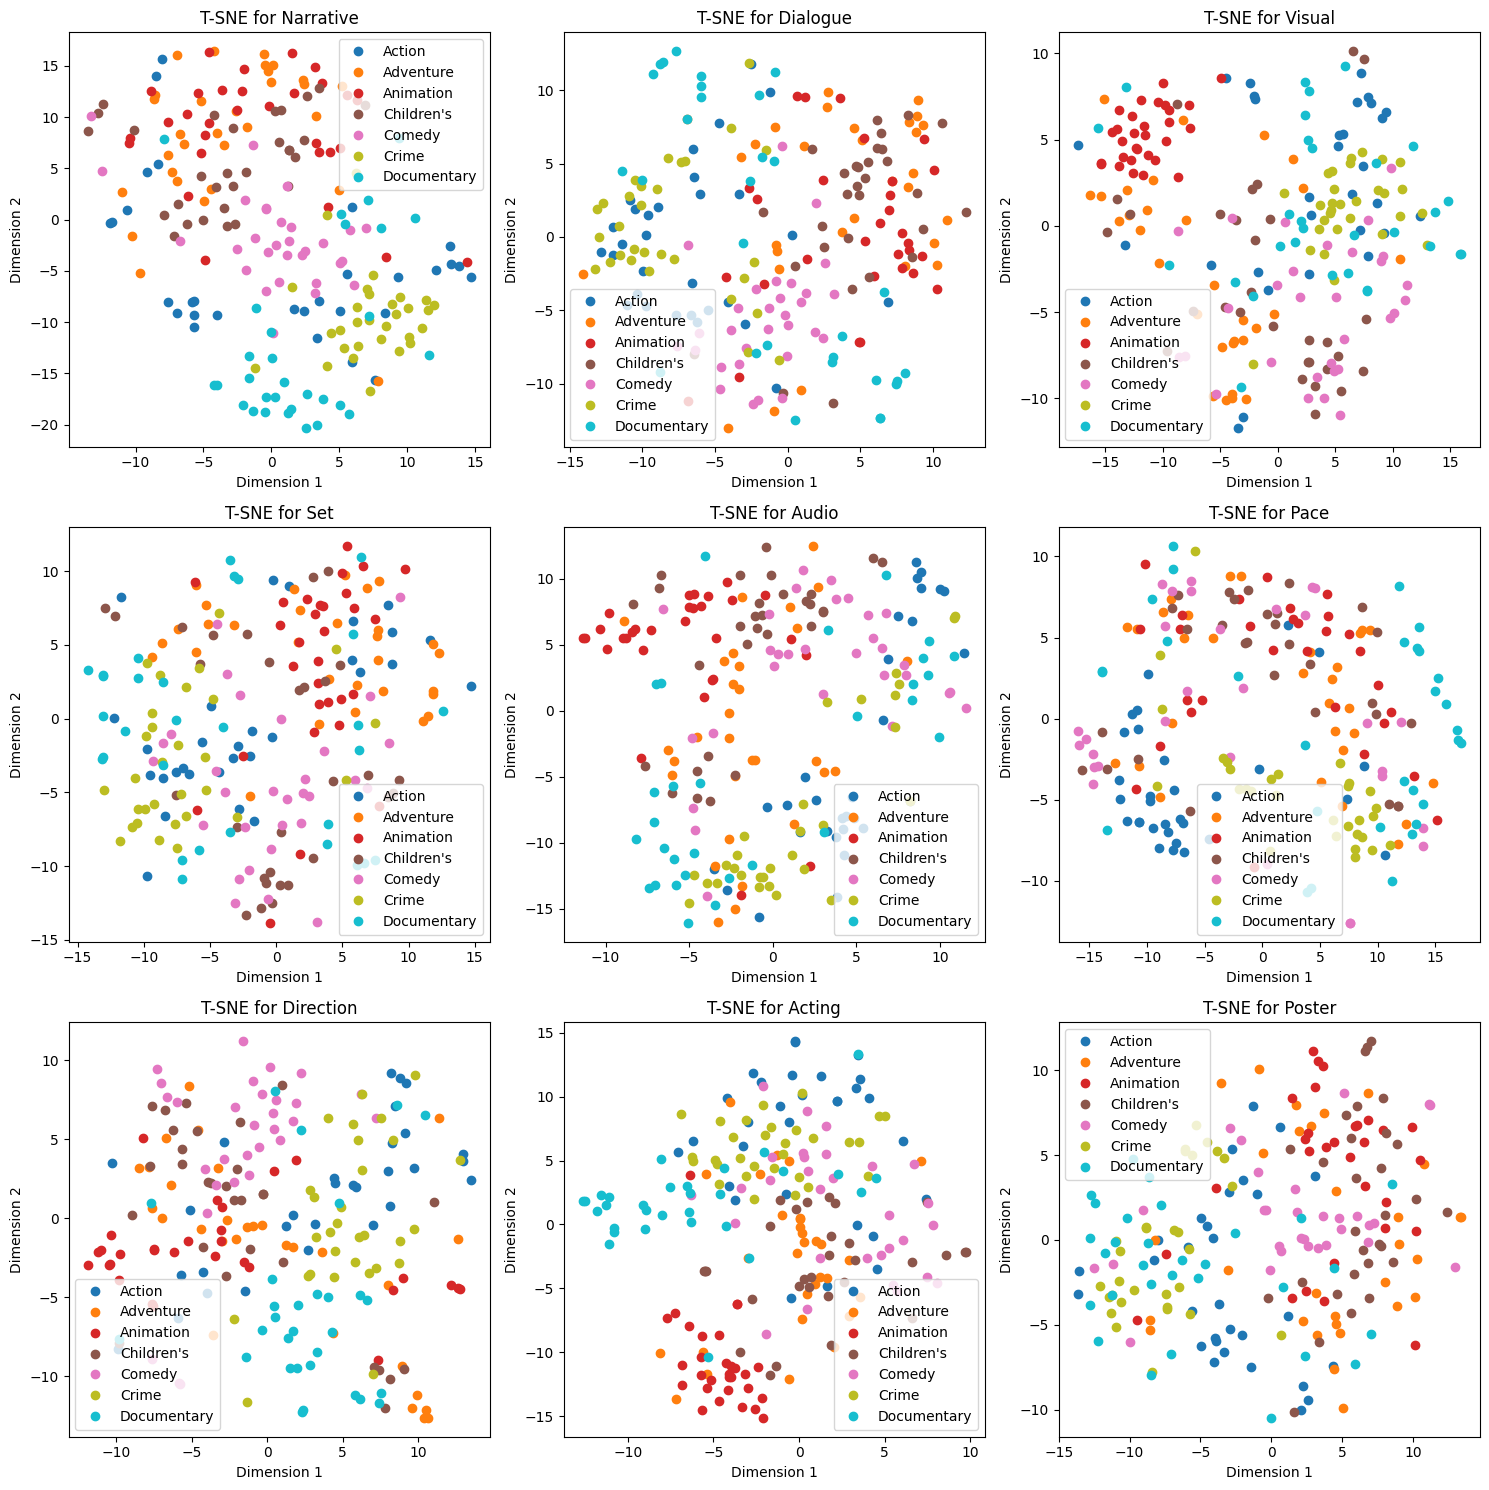

In [93]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

# Assuming that movies, aspects, and embedding_data are already defined.
# Get the unique genres from the movies dictionary.
unique_genres = list(movies.keys())

# Prepare a color map using matplotlib's tab10 colormap.
colors = plt.get_cmap("tab10", len(unique_genres))
genre_color_map = {genre: colors(i) for i, genre in enumerate(unique_genres)}

# Initialize T-SNE.
tsne = TSNE(n_components=2, random_state=42)

# Create a 3x3 subplot grid.
fig, axes = plt.subplots(3, 3, figsize=(15, 15))
axes = axes.flatten()  # Flatten to simplify the iteration.

# For each aspect, perform T-SNE and create a scatter plot on its respective subplot.
for ax, aspect in zip(axes, aspects):
    # Convert list of embeddings into a NumPy array.
    embeddings = np.array([item["embedding"] for item in embedding_data[aspect]])
    
    # Apply T-SNE to reduce dimensions.
    tsne_result = tsne.fit_transform(embeddings)
    
    # Plot each movie as a point; movie titles are not annotated.
    for idx, point in enumerate(tsne_result):
        item = embedding_data[aspect][idx]
        ax.scatter(point[0], point[1], color=genre_color_map[item["genre"]])
    
    # Create a custom legend for the genres.
    legend_handles = []
    for genre, color in genre_color_map.items():
        legend_handles.append(plt.Line2D([], [], marker="o", linestyle="", color=color, label=genre))
    ax.legend(handles=legend_handles)
    
    ax.set_title(f"T-SNE for {aspect}")
    ax.set_xlabel("Dimension 1")
    ax.set_ylabel("Dimension 2")

# Hide any unused subplots if the number of aspects is less than 9.
for ax in axes[len(aspects):]:
    ax.axis('off')

plt.tight_layout()
plt.show()
